## 1. Business Understanding
- What is the problem?
We need to bomb civilians and have customer locations to accomplish that
- What do we want to achieve?

## 2. Data Understanding

### Import Libraries

In [1]:
import pandas as pd
import numpy as np
import time
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report,silhouette_score

### Load Data

In [2]:
df = pd.read_csv("../datasets/drone_cust_locations.csv", sep=';')
df

,clientid,x,y
0,1,622.771572,164.857623
1,2,416.357298,630.193634
2,3,292.735020,567.333231
3,4,737.211288,166.225676
4,5,540.475375,682.912298
...,...,...,...
5951,5952,832.857394,616.861410
5952,5953,242.734500,490.325092
5953,5954,108.690847,758.833921
5954,5955,803.251074,430.740623


### Basic Information

In [3]:
df.info()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 5956 entries, 0 to 5955
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   clientid  5956 non-null   int64  
 1   x         5956 non-null   float64
 2   y         5956 non-null   float64
dtypes: float64(2), int64(1)
memory usage: 139.7 KB


,clientid,x,y
count,5956.000000,5956.000000,5956.000000
mean,2978.500000,508.823177,427.554772
std,1719.493433,271.061462,289.044640
min,1.000000,0.017692,0.043285
25%,1489.750000,282.582920,170.079921
50%,2978.500000,518.100892,397.786441
75%,4467.250000,727.156497,669.982518
max,5956.000000,999.533215,999.731720


## 3. Data Preparation

### Check Missing Values

We can see that the data is complete and there is no missing values

In [4]:
df.isnull().sum()

clientid    0
x           0
y           0
dtype: int64

### Visualizing data

From the visualization we can see that theres a large empty space in the middle

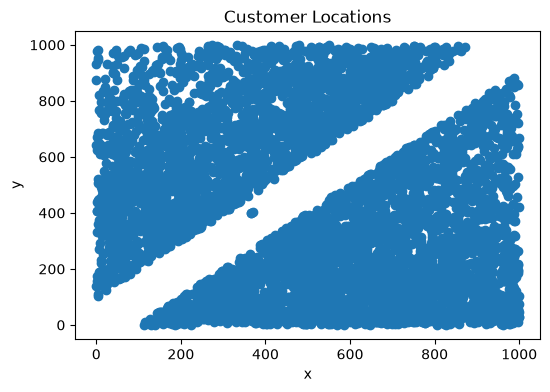

In [5]:
fig, ax = plt.subplots(figsize=(6, 4))

ax.scatter(df['x'], df['y'])
ax.set(xlabel='x', ylabel='y', title='Customer Locations')
plt.show()

## 4. Modeling

In [6]:
X = df.drop(columns=['clientid'])

### Plotting function

Lets create a reusable plotting function that lets us adjust algorithm (`kmeans` and `agglomerative`), `k` for clusters, `init` and `random_state` while the former 2 are only available for `kmeans`. We also add cluster info to the original dataframe here

In [7]:
def cluster_plot(algo, n_clusters, init=None, random_state=None):
    if algo == 'kmeans':
        algorithm = KMeans(init=init,n_clusters=n_clusters,random_state=random_state)
    elif algo == 'agglomerative':
        algorithm = AgglomerativeClustering(n_clusters=n_clusters)
    else:
        return
    clusters = algorithm.fit_predict(X)
    X['cluster'] = clusters
    df['depot'] = X['cluster']
    fig, ax = plt.subplots(figsize=(6, 4))
    for cluster, group in X.groupby('cluster'):
        ax.scatter(group['x'],group['y'],label=f'Cluster {cluster}')
    centers = X.groupby('cluster')[['x', 'y']].mean()
    ax.scatter(centers['x'],centers['y'],marker='X',s=200,label='Centroids',color='black')
    ax.legend()
    ax.set(xlabel='x',ylabel='y',title=f'{algo.title()} - Client Clusters')
    plt.show()

The assignment tells use to use `k=3` so lets use `k=3`

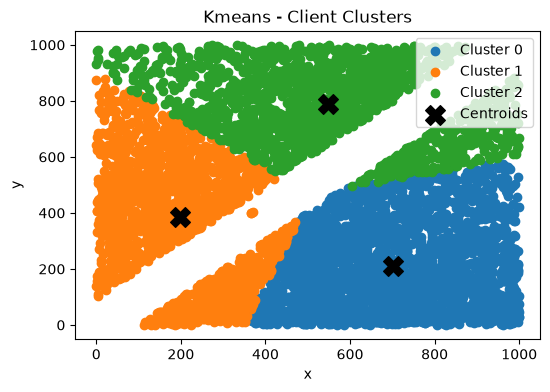

In [8]:
cluster_plot('kmeans',3,'random',42)

### Adding depot info to location frame

Lets add depot num to the dataframe

In [9]:
df['depot'] = X['cluster']
df.head(10)

,clientid,x,y,depot
0,1,622.771572,164.857623,0
1,2,416.357298,630.193634,2
2,3,292.735020,567.333231,1
3,4,737.211288,166.225676,0
4,5,540.475375,682.912298,2
5,6,535.469492,318.439661,0
6,7,640.380050,870.833221,2
7,8,235.772075,359.048203,1
8,9,481.896884,661.491838,2
9,10,730.032789,312.177817,0


### Choosing optimal cluster amount

Lets create clusters and draw wcss diagram, from which we can see that optimal amount of clusters is 5 when a sharp decline stops

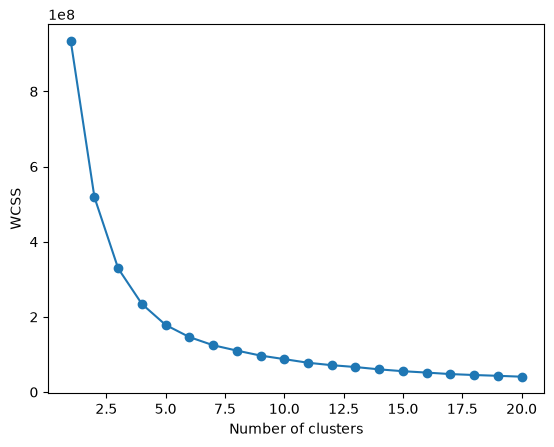

In [10]:
wcss = []
for i in range(1,21):
    model = KMeans(init='random', n_clusters=i, random_state=42).fit(X)
    wcss.append(model.inertia_)
    
plt.plot(range(1,21), wcss, 'o-')
plt.xlabel('Number of clusters')
plt.ylabel('WCSS')
plt.show()

### Different cluster amounts

From the above graph we can see that sharp decline ends at `k=5` and continues to go down, lets also try `k=10` clusters. `k=20`
would likely be overkill so lets just cut it at `k=10`

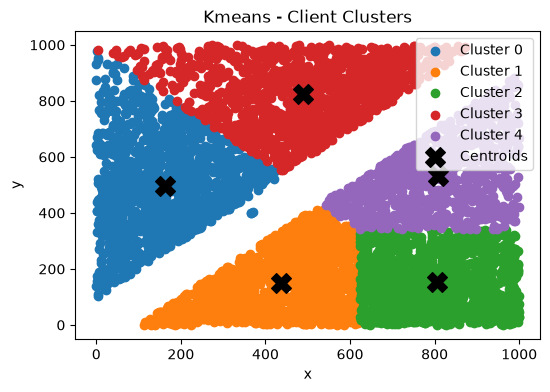

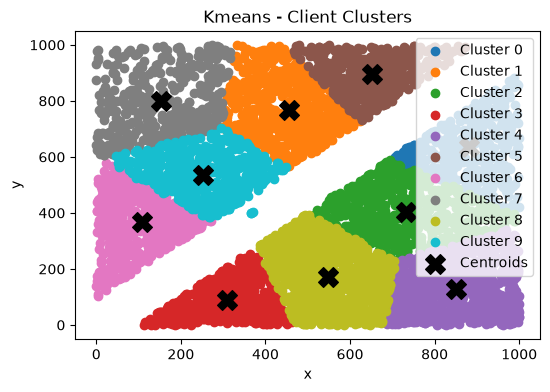

In [11]:
cluster_plot('kmeans',5,'random',42)
cluster_plot('kmeans',10,'random',42)

### Computation time

After running below cell few times, general observation is that `2`, `3`, `5` are fastest at around 0.05-0.07 seconds while `4` depots being an outlier being around 0.1, same as `10` and `20`. For our use case the times arent meaningfully different from eachother, but something to consider when scaling.

In [12]:
X = df[['x', 'y']]
for k in [2, 3, 4, 5, 10, 20]:
    start = time.perf_counter()
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X)
    end = time.perf_counter()
    print(f"Depots: {k}, computation time: {end - start:.6f} seconds")

Depots: 2, computation time: 0.045064 seconds
Depots: 3, computation time: 0.055317 seconds
Depots: 4, computation time: 0.095972 seconds
Depots: 5, computation time: 0.058533 seconds
Depots: 10, computation time: 0.103001 seconds
Depots: 20, computation time: 0.115013 seconds


### Agglomerative clustering

Lets start by measuring the times, we can see that agglomerative clustering times are consistently 4-5 times longer, again with our current dataset its not a problem but scaling would cause issues. However unlike kmeans the variation between different cluster sizes are smaller % wise.

In [13]:
X = df[['x', 'y']]
for k in [2, 3, 4, 5, 10, 20]:
    start = time.perf_counter()
    clustering = AgglomerativeClustering(
        n_clusters=k,
        linkage='ward'
    )
    labels = clustering.fit_predict(X)
    end = time.perf_counter()
    print(f"Depots: {k}, "f"computation time: {end - start:.6f} seconds")

Depots: 2, computation time: 0.473876 seconds
Depots: 3, computation time: 0.390393 seconds
Depots: 4, computation time: 0.430184 seconds
Depots: 5, computation time: 0.416008 seconds
Depots: 10, computation time: 0.465821 seconds
Depots: 20, computation time: 0.445772 seconds


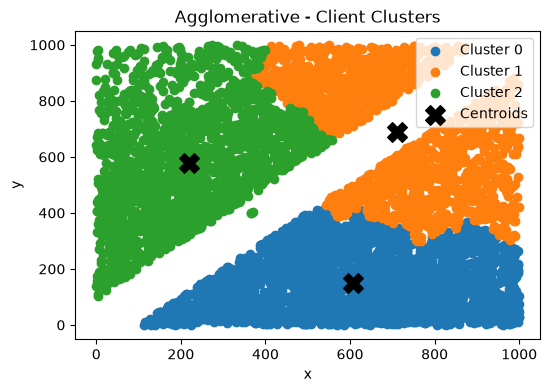

In [14]:
cluster_plot(n_clusters=3,algo='agglomerative')

Using agglomerative clustering for wcss we can see the see the same values as with `kmeans`, `k=5` and `k=10` being good candidates for amount of depots

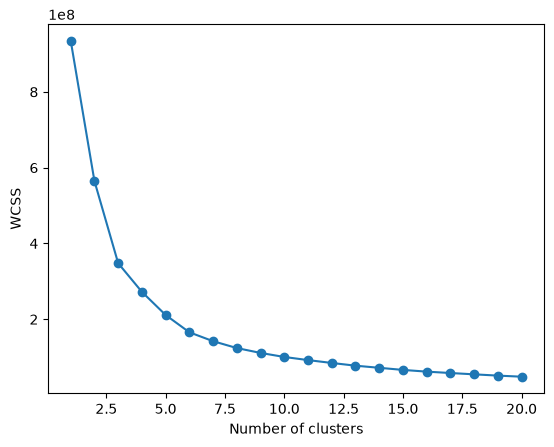

In [15]:
wcss = []
for i in range(1, 21):
    model = AgglomerativeClustering(n_clusters=i)
    labels = model.fit_predict(X)
    X_temp = X.copy()
    X_temp['cluster'] = labels
    wcss_i = 0
    for _, group in X_temp.groupby('cluster'):
        center = group[['x', 'y']].mean()
        wcss_i += ((group[['x', 'y']] - center) ** 2).sum().sum()
    wcss.append(wcss_i)

plt.plot(range(1, 21), wcss, 'o-')
plt.xlabel('Number of clusters')
plt.ylabel('WCSS')
plt.show()

Plotting `agglomerative` clusters. We can see that they are less "clean" than with `kmeans`. As noted earlier the performance is significantly worse thus there is no reason to use `agglomerative` instead of `kmeans`.

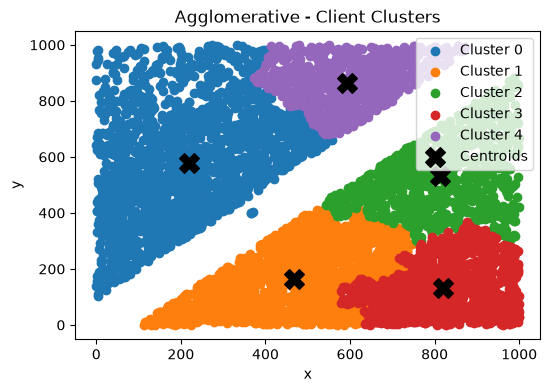

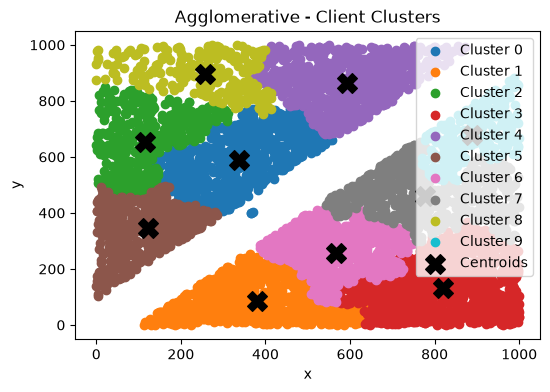

In [16]:
cluster_plot(n_clusters=5,algo='agglomerative')
cluster_plot(n_clusters=10,algo='agglomerative')

In [18]:
X

,x,y,cluster
0,622.771572,164.857623,3
1,416.357298,630.193634,0
2,292.735020,567.333231,0
3,737.211288,166.225676,3
4,540.475375,682.912298,4
...,...,...,...
5951,832.857394,616.861410,9
5952,242.734500,490.325092,0
5953,108.690847,758.833921,2
5954,803.251074,430.740623,7


## 5. Evaluation

In [17]:
# Check how well the model performs

# Example:
# model.score(X_test, y_test)

## 6. Deployment / Conclusion

### Results
- What did we find?
- How accurate was the model?
- Did we solve the original problem?

### Conclusion
Write a short conclusion here.